In [52]:
import numpy as np
import pandas as plt
import matplotlib.pyplot as plt
import scipy.stats as sps

# Обоснование проходного порога

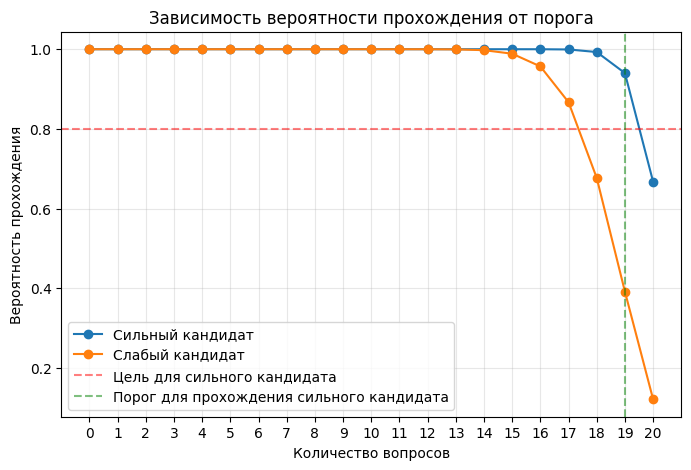

In [53]:
n = 20
p_strong = 0.98
p_weak = 0.90
x = np.arange(0, n+1)

strong_pass = [1 - sps.binom.cdf(t-1, n, p_strong) for t in x] # вероятность прохождения сильного кандидата
weak_pass = [1 - sps.binom.cdf(t-1, n, p_weak) for t in x] # вероятность прохождения слабого кандидата

plt.figure(figsize=(8,5))
plt.plot(x, strong_pass, label = 'Сильный кандидат', marker='o')
plt.plot(x, weak_pass, label = 'Слабый кандидат', marker='o')

plt.title('Зависимость вероятности прохождения от порога')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность прохождения')

plt.axhline(y=0.8, linestyle = '--',label='Цель для сильного кандидата', color='red', alpha=0.5)
plt.axvline(x=19, linestyle = '--',label='Порог для прохождения сильного кандидата', color='green', alpha=0.5)

plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Требование к числу вопросов и проходному порогу при уровне "Как на работе"

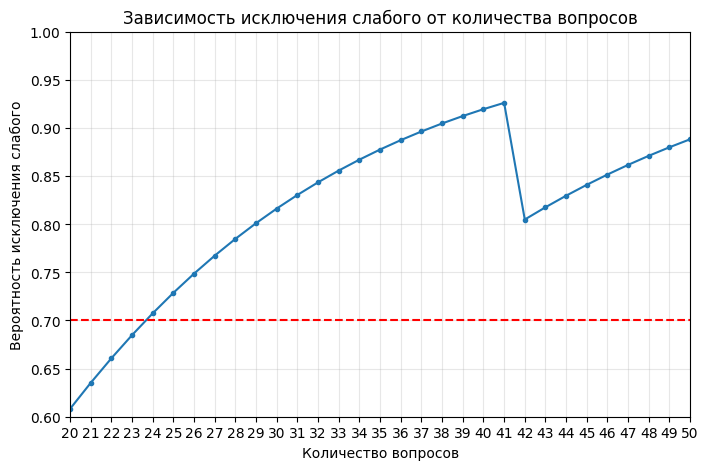

N=24, порог=23, слабый исключается: 0.708, сильный проходит: 0.917


In [54]:
results = []

for N in range(5, 51):
    best_exc = 0
    best_t = None
    strong = 0

    for t in range(N + 1):
        strong_p = 1 - sps.binom.cdf(t-1, N, p_strong)
        weak_exc = sps.binom.cdf(t-1, N, p_weak)

        if strong_p >= 0.80 and weak_exc > best_exc:
            best_exc = weak_exc
            best_t = t
            strong = strong_p

    if best_t is not None:
        results.append([N, best_t, best_exc, strong])

results = np.array(results)
plt.figure(figsize=(8,5))
plt.plot(results[:, 0], results[:, 2], marker='.')
plt.axhline(0.7, color='red', linestyle='--')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность исключения слабого')
plt.title('Зависимость исключения слабого от количества вопросов')
plt.xticks(np.arange(0, 51))
plt.xlim(20, 50)
plt.ylim(0.6, 1)
plt.grid(True, alpha=0.3)
plt.show()

for row in results:
    if row[2] >= 0.70:
        print(f"N={int(row[0])}, порог={int(row[1])}, слабый исключается: {row[2]:.3f}, сильный проходит: {row[3]:.3f}")
        break

# Требование к числу вопросов и проходному порогу при уровне "Проще, чем на работе"

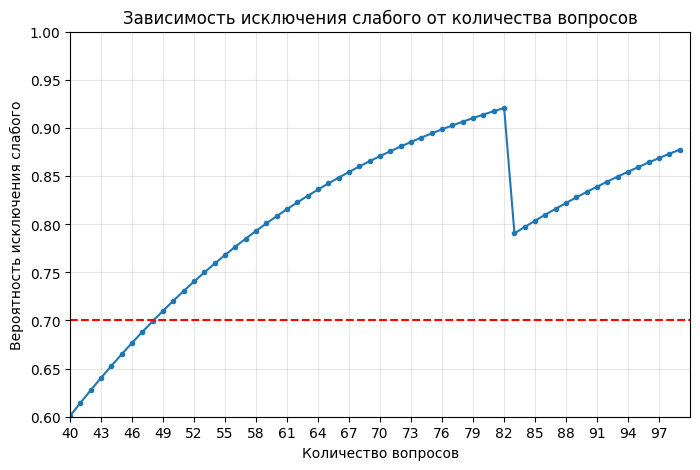

N=49, порог=48, слабый исключается: 0.710, сильный проходит: 0.914


In [55]:
results = []

p_strong = 0.99
p_weak = 0.95

for N in range(1, 100):
    best_exc = 0
    best_t = None
    strong = 0

    for t in range(N + 1):
        strong_p = 1 - sps.binom.cdf(t-1, N, p_strong)
        weak_exc = sps.binom.cdf(t-1, N, p_weak)

        if strong_p >= 0.80 and weak_exc > best_exc:
            best_exc = weak_exc
            best_t = t
            strong = strong_p

    if best_t is not None:
        results.append([N, best_t, best_exc, strong])

results = np.array(results)
plt.figure(figsize=(8,5))
plt.plot(results[:, 0], results[:, 2], marker='.')
plt.axhline(0.7, color='red', linestyle='--')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность исключения слабого')
plt.title('Зависимость исключения слабого от количества вопросов')
plt.xticks(np.arange(40, 100, 3))
plt.xlim(40, 100)
plt.ylim(0.6, 1)
plt.grid(True, alpha=0.3)
plt.show()

for row in results:
    if row[2] >= 0.70:
        print(f"N={int(row[0])}, порог={int(row[1])}, слабый исключается: {row[2]:.3f}, сильный проходит: {row[3]:.3f}")
        break

# Требование к числу вопросов и проходному порогу при уровне "Сложнее, чем на работе"

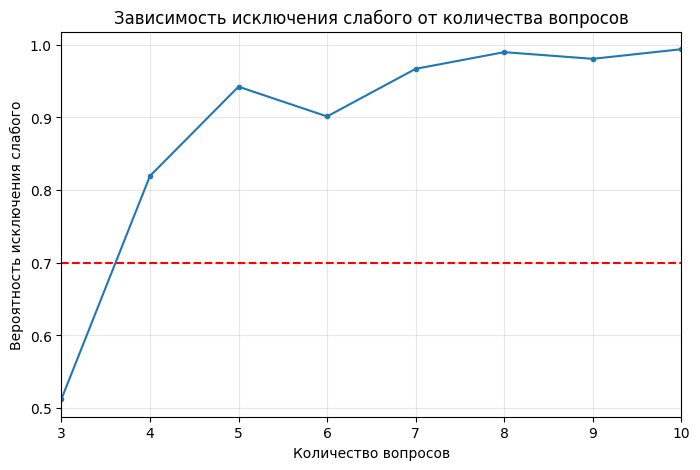

N=4, порог=2, слабый исключается: 0.819, сильный проходит: 0.916


In [56]:
results = []

p_strong = 0.7
p_weak = 0.2

for N in range(1, 11):
    best_exc = 0
    best_t = None
    strong = 0

    for t in range(N + 1):
        strong_p = 1 - sps.binom.cdf(t-1, N, p_strong)
        weak_exc = sps.binom.cdf(t-1, N, p_weak)

        if strong_p >= 0.80 and weak_exc > best_exc:
            best_exc = weak_exc
            best_t = t
            strong = strong_p

    if best_t is not None:
        results.append([N, best_t, best_exc, strong])

results = np.array(results)
plt.figure(figsize=(8,5))
plt.plot(results[:, 0], results[:, 2], marker='.')
plt.axhline(0.7, color='red', linestyle='--')
plt.xlabel('Количество вопросов')
plt.ylabel('Вероятность исключения слабого')
plt.title('Зависимость исключения слабого от количества вопросов')
plt.xticks(np.arange(0, 11))
plt.xlim(3, 10)
plt.grid(True, alpha=0.3)
plt.show()

for row in results:
    if row[2] >= 0.70:
        print(f"N={int(row[0])}, порог={int(row[1])}, слабый исключается: {row[2]:.3f}, сильный проходит: {row[3]:.3f}")
        break